In [1]:
import numpy as np 
import torch
import pyPLNmodels
from pyPLNmodels.utils import build_block_Sigma, C_from_Sigma, sample_PLN
import matplotlib.pyplot as plt 
import torch.nn as nn 
import seaborn as sns
import torch.nn.functional as F
from pyPLNmodels.utils import log_stirling
import threading

In [2]:
torch.set_printoptions(precision=3)


In [3]:
d = 2
n = 200;  p = 50
q = 5

In [4]:
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else : 
    device = torch.device('cpu')
    
#device = torch.device('cpu') # think I can't use RTX A5000 right now, will check this later. 

torch.cuda.is_available()
#device = torch.device('cpu')

True

In [5]:
device

device(type='cuda', index=0)

In [7]:
# 0 est pas mal 
#torch.manual_seed(0)
Sigma_sampling = 1*torch.from_numpy(build_block_Sigma(p,10))/1 #+ 0.5*torch.eye(p)
#Sigma_sampling = torch.eye(p)

true_C = C_from_Sigma(Sigma_sampling, q).to(device)
true_Sigma_sampling = true_C@(true_C.T)
true_beta =torch.randn((d, p), device = device)/3
covariates = torch.randn((n,d)).to(device)*0
O =  0*torch.randint(2,(n,p)).to(device)
Y, Z, _  = sample_PLN(true_C,true_beta, O, covariates)

In [9]:
Y.max()

tensor(196., device='cuda:0')

In [10]:
def plot(model):
    '''
    Plot a model, in most casesa neural network
    It will plot the training loss through epoch, and also the test loss. 
    '''
    train_length = len(model.training_loss_list)
    fig, ax = plt.subplots(2,1)
    ax[0].plot(np.arange(train_length), model.training_loss_list, label = 'Training_loss') 
    ax[0].set_yscale('log')
    try:
        test_length = len(model.test_loss_list)
        ax[1].plot(np.arange(test_length), model.test_loss_list, label = 'Test loss')
    except: 
        print('The model has not been tested, wont plot the test loss') 
    ax[0].legend()
    ax[1].legend()
    
    plt.show()


def get_batch(X,y= None, batch_size = 50):
    '''Get the batches required to do a  minibatch gradient ascent.

    Args:
        X: torch.tensor of size (n, n_features).
        y: torch.tensor. Target, if supervised model, of size n. 
            Default is None (unsupervised model)   
        batch_size: int. The batch size. Should be lower than n. Default is 50
       
    Returns: A generator. Will generate n//batch_size + 1 batches of
        size batch_size (except the last one since the rest of the
        division is not always 0)
    '''
    n = X.shape[0]


    indices = np.arange(n)
    # Shuffle the indices to avoid a regular path.
    np.random.shuffle(indices)
    # Set the batch size of the model to the right size
    # get the number of batches and the size of the last one.
    nb_full_batch, last_batch_size = n // batch_size, n % batch_size
    if y == None: 
        for i in range(nb_full_batch):
            yield X[indices[i * batch_size: (i + 1) * batch_size]]
                   
        # Last batch
        # Set the batch size of the model to the right size
        if last_batch_size != 0:
            yield X[indices[-last_batch_size:]]
                   
        
    else: 
        if y.shape[0]!= n:
            raise AttributeError('X and y does not have the same shape')
        for i in range(nb_full_batch):
            yield (X[indices[i * batch_size: (i + 1) * batch_size]],
                   y[indices[i *batch_size: (i + 1) * batch_size]],
                   )
        # Last batch
        # Set the batch size of the model to the right size
        if last_batch_size != 0:
            yield (X[indices[-last_batch_size:]],
                   y[indices[-last_batch_size:]],
                   )
            


In [11]:
class PLN_encoder(nn.Module):
    
    def __init__(self, input_dim, q): 
        super().__init__()        
        self.input_dim = input_dim 
        self.q = q 

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 30), # (N, 784) -> (N, 128)
            nn.ReLU(),
            nn.Linear(30, 20),
            nn.ReLU(),
            nn.Linear(20, 12),
            nn.ReLU(),
            #nn.Linear(12, q) # -> N, 3
        )
        
        self.z_mean = torch.nn.Linear(12, self.q)
        self.z_log_var = torch.nn.Linear(12, self.q)
        
        self.decoder = nn.Sequential(
            nn.Linear(q, 12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            #nn.Sigmoid()
        )
        self.criterion = nn.MSELoss()
        self.training_loss_list = []
        self.test_loss_list = []
        self.min_test_loss = 1e30
        
        
        
    def encoding_fn(self, x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var)
        return encoded
        
    def reparameterize(self, z_mu, z_log_var):
        eps = torch.randn(z_mu.size(0), z_mu.size(1)).to(device) 
        z = z_mu# + eps * torch.exp(z_log_var/2.) 
        return z
        
    def forward(self, x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var)
        #decoded = self.decoder(encoded)
        return z_mean, z_log_var#, decoded
    
    
    def _train(self,Y,O,covariates, num_epochs, batch_size, 
               optimizer = torch.optim.Adam, model_optimizer = torch.optim.Rprop, 
               lr = 0.001, lr_model = 0.01, verbose = False):
        self.Y = Y
        self.O = O
        self.covariates = covariates
        self.q = q 
        self.d = d
        self.n = n 
        self.p = p
        self.C = torch.randn((self.p, self.q)).to(device)
        self.beta = torch.randn((self.d, self.p)).to(device)
        self.M = torch.randn((self.n, self.q)).to(device)
        self.S = torch.randn((self.n, self.q)).to(device)
        self.model_optimizer = model_optimizer([self.beta, self.C, self.M, self.S], lr = lr_model )
        self.optimizer = optimizer(self.parameters(),lr=lr)
        self.train()
        self.to(device)
        self.mse_loss = nn.MSELoss(reduction = 'sum')
        self.beta.requires_grad_(True)
        self.M.requires_grad_(True)
        self.S.requires_grad_(True)
        self.C.requires_grad_(True)
        

        
        #if len(Y.shape) == 3:
        #    X_train = X_train.unsqueeze(1)
        self.train()

        for i,epoch in enumerate(range(num_epochs)):
            training_loss = 0 
            cmpt = 0 
            for Y_b, O_b, covariates_b, indices in self.get_YOcovbatch(batch_size = batch_size):
                self.Y_b = Y_b 
                self.O_b = O_b
                self.covariates_b = covariates_b
                z_mean, z_log_var = self.forward(Y_b)
                #print('decode, ', decoded.shape)
                KL = self.my_loss(z_mean, z_log_var )
                #loss = KL + self.mse_loss(decoded, img)
                '''
                kl_div = -0.5 * torch.sum(1 + z_log_var 
                          - z_mean**2 
                          - torch.exp(z_log_var), 
                          axis=1) # sum over latent dimension
                batchsize = kl_div.size(0)
                kl_div = kl_div.mean() # average over batch dimension

                pixelwise = self.criterion(decoded, img)
                pixelwise = pixelwise.view(batchsize, -1).sum(axis=1) # sum over pixels
                pixelwise = pixelwise.mean() # average over batch dimension
                crit = nn.MSELoss()(decoded, img)
                loss = crit #+ kl_div 
                
                loss = 1*pixelwise + kl_div
                #print('pixelwise crit ', pixelwise)
                '''
                simple_var = False
                if simple_var == False : 
                    loss = -self.elbo_loss(z_mean, z_log_var)
                else: 
                    loss = -ELBO_PCA(self.Y,self.O,self.covariates, self.M, self.S, self.C, self.beta)
                    
                #loss = self.criterion(decoded, img)
                self.optimizer.zero_grad()
                self.model_optimizer.zero_grad()
                loss.backward()
                if simple_var == False: 
                    self.optimizer.step()
                self.model_optimizer.step()
                training_loss+= loss.item()
                cmpt += 1
            self.training_loss_list.append(training_loss/(self.n))
            if verbose : 
                print(f'Epoch:{epoch+1}, Training loss:{training_loss/(self.n):.4f}')
            ## Early stopping 
        print('Training finished')
        
    def my_loss(self, mu, logvar): 
        return - 1/2* torch.sum(1 + logvar - mu**2 - torch.exp(logvar))
    
    def elbo_loss(self, mu, log_var): 
        return ELBO_PCA(self.Y_b,self.O_b,self.covariates_b, mu, torch.exp(log_var), self.C, self.beta)
    
            
    def get_YOcovbatch(self,batch_size):
        '''Get the batches required to do a  minibatch gradient ascent.

        Args:
            batch_size: int. The batch size. Should be lower than n.

        Returns: A generator. Will generate n//batch_size + 1 batches of
            size batch_size (except the last one since the rest of the
            division is not always 0)
        '''
        indices = np.arange(self.n)
        # Shuffle the indices to avoid a regular path.
        np.random.shuffle(indices)
        # Set the batch size of the model to the right size
        self.batch_size = batch_size
        # get the number of batches and the size of the last one.
        nb_full_batch, last_batch_size = self.n // batch_size, self.n % batch_size
        for i in range(nb_full_batch):
            yield (self.Y[indices[i * batch_size: (i + 1) * batch_size]],
                   self.O[indices[i * batch_size: (i + 1) * batch_size]],
                   self.covariates[indices[i *
                                           batch_size: (i + 1) * batch_size]],
                   indices[i * batch_size: (i + 1) * batch_size]
                   )
        # Last batch
        # Set the batch size of the model to the right size
        if last_batch_size != 0:
            self.batch_size = last_batch_size
            yield (self.Y[indices[-last_batch_size:]],
                   self.O[indices[-last_batch_size:]],
                   self.covariates[indices[-last_batch_size:]],
                   indices[-last_batch_size:]
                   )

In [12]:
class PLN_VAE(nn.Module):
    
    def __init__(self, input_dim, q): 
        super().__init__()        
        self.input_dim = input_dim 
        self.q = q 

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 40), # (N, 784) -> (N, 128)
            nn.ReLU(),
            nn.Linear(40, 30),
            nn.ReLU(),
            nn.Linear(30, 12),
            nn.ReLU(),
            #nn.Linear(12, q) # -> N, 3
        )
        
        self.z_mean = torch.nn.Linear(12, self.q)
        self.z_log_var = torch.nn.Linear(12, self.q)
        
        self.decoder = nn.Sequential(
            nn.Linear(q, 12),
            nn.ReLU(),
            nn.Linear(12, 30),
            nn.ReLU(),
            nn.Linear(30, 40),
            nn.ReLU(),
            nn.Linear(40, input_dim),
            #nn.Sigmoid()
        )
        self.criterion = nn.MSELoss()
        self.training_loss_list = []
        self.test_loss_list = []
        self.min_test_loss = 1e30
        
        
    def recon_loss(self, phiz): 
        return -torch.sum(-torch.exp(self.O_b + phiz) + torch.multiply(phiz + self.O_b,self.Y_b) - log_stirling(self.Y_b))
    
    def KL_loss(self, mu, log_var):
        return -0.5 * torch.sum(1 + log_var - mu**2 - torch.exp(log_var))
        
        
    def encoding_fn(self, x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var) # just add a gaussian noise 
        return encoded
        
    def reparameterize(self, mu, log_var):
        eps = torch.randn(mu.size(0), mu.size(1)).to(device) 
        z = mu + eps * torch.exp(log_var/2.) 
        return z
        
    def forward(self, x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var) ## add a gaussian noise to the mean and var 
        decoded = self.decoder(encoded)
        return z_mean, z_log_var, decoded
    
    
    def _train(self,Y,O,covariates, num_epochs, batch_size, 
               optimizer = torch.optim.Adam, model_optimizer = torch.optim.Rprop, 
               lr = 0.001, lr_model = 0.01, verbose = False):
        self.Y = Y
        self.O = O
        self.covariates = covariates
        self.q = q 
        self.d = d
        self.n = n 
        self.p = p
        self.C = torch.randn((self.p, self.q)).to(device)
        self.beta = torch.randn((self.d, self.p)).to(device)
        self.M = torch.randn((self.n, self.q)).to(device)
        self.S = torch.randn((self.n, self.q)).to(device)
        self.model_optimizer = model_optimizer([self.beta, self.C, self.M, self.S], lr = lr_model )
        self.optimizer = optimizer(self.parameters(),lr=lr)
        self.train()
        self.to(device)
        self.mse_loss = nn.MSELoss(reduction = 'sum')
        self.beta.requires_grad_(True)
        self.M.requires_grad_(True)
        self.S.requires_grad_(True)
        self.C.requires_grad_(True)
        

        
        #if len(Y.shape) == 3:
        #    X_train = X_train.unsqueeze(1)
        self.train()

        for i,epoch in enumerate(range(num_epochs)):
            training_loss = 0 
            cmpt = 0 
            for Y_b, O_b, covariates_b, indices in self.get_YOcovbatch(batch_size = batch_size):
                self.Y_b = Y_b 
                self.O_b = O_b
                self.covariates_b = covariates_b
                z_mean, z_log_var, decoded = self.forward(Y_b)
                #print('decode, ', decoded.shape)
                KL = self.KL_loss(z_mean, z_log_var)
                recon_loss = self.recon_loss(decoded) 
                loss = KL + recon_loss 
                self.optimizer.zero_grad()
                #self.model_optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                #self.model_optimizer.step()
                training_loss+= loss.item()
                cmpt += 1
            self.training_loss_list.append(training_loss/(self.n))
            if verbose : 
                print(f'Epoch:{epoch+1}, Training loss:{training_loss/(self.n):.4f}')
            ## Early stopping 
        print('Training finished')
        
    
    def elbo_loss(self, mu, log_var): 
        return ELBO_PCA(self.Y_b,self.O_b,self.covariates_b, mu, torch.exp(log_var), self.C, self.beta)
    
            
    def get_YOcovbatch(self,batch_size):
        '''Get the batches required to do a  minibatch gradient ascent.

        Args:
            batch_size: int. The batch size. Should be lower than n.

        Returns: A generator. Will generate n//batch_size + 1 batches of
            size batch_size (except the last one since the rest of the
            division is not always 0)
        '''
        indices = np.arange(self.n)
        # Shuffle the indices to avoid a regular path.
        np.random.shuffle(indices)
        # Set the batch size of the model to the right size
        self.batch_size = batch_size
        # get the number of batches and the size of the last one.
        nb_full_batch, last_batch_size = self.n // batch_size, self.n % batch_size
        for i in range(nb_full_batch):
            yield (self.Y[indices[i * batch_size: (i + 1) * batch_size]],
                   self.O[indices[i * batch_size: (i + 1) * batch_size]],
                   self.covariates[indices[i *
                                           batch_size: (i + 1) * batch_size]],
                   indices[i * batch_size: (i + 1) * batch_size]
                   )
        # Last batch
        # Set the batch size of the model to the right size
        if last_batch_size != 0:
            self.batch_size = last_batch_size
            yield (self.Y[indices[-last_batch_size:]],
                   self.O[indices[-last_batch_size:]],
                   self.covariates[indices[-last_batch_size:]],
                   indices[-last_batch_size:]
                   )

In [13]:
def ELBO_PCA(Y, O, covariates, M, S, C, beta):
    '''compute the ELBO with a PCA parametrization'''
    n = Y.shape[0]
    q = C.shape[1]
    # Store some variables that will need to be computed twice
    A = O + torch.mm(covariates, beta) + torch.mm(M, C.T)
    SrondS = torch.multiply(S, S)
    # Next, we add the four terms of the ELBO_PCA
    YA = torch.sum(torch.multiply(Y, A))
    moinsexpAplusSrondSCCT = torch.sum(-torch.exp(A + 1 / 2 *
                       torch.mm(SrondS, torch.multiply(C, C).T)))
    moinslogSrondS = 1 / 2 * torch.sum(torch.log(SrondS))
    MMplusSrondS = torch.sum(-1 / 2 * (torch.multiply(M, M) + torch.multiply(S, S)))
    log_stirlingY = torch.sum(log_stirling(Y))

    return YA + moinsexpAplusSrondSCCT + moinslogSrondS + MMplusSrondS - log_stirlingY + n * q / 2

In [14]:
lvae = PLN_VAE(p,q)
lvae._train(Y,O,covariates, 200, batch_size = 15 ,optimizer = torch.optim.RMSprop, lr = 0.0001, lr_model = 0.001, verbose = True)

Epoch:1, Training loss:121.8059
Epoch:2, Training loss:121.2888
Epoch:3, Training loss:120.8891
Epoch:4, Training loss:120.5259
Epoch:5, Training loss:120.0556
Epoch:6, Training loss:119.9503
Epoch:7, Training loss:119.4478
Epoch:8, Training loss:119.1232
Epoch:9, Training loss:118.6525
Epoch:10, Training loss:118.0702
Epoch:11, Training loss:117.9121
Epoch:12, Training loss:117.0290
Epoch:13, Training loss:117.1791
Epoch:14, Training loss:116.2658
Epoch:15, Training loss:116.1023
Epoch:16, Training loss:114.3037
Epoch:17, Training loss:111.3864
Epoch:18, Training loss:111.3003
Epoch:19, Training loss:112.4393
Epoch:20, Training loss:110.8053
Epoch:21, Training loss:110.0787
Epoch:22, Training loss:104.8136
Epoch:23, Training loss:106.4546
Epoch:24, Training loss:105.8416
Epoch:25, Training loss:104.2069
Epoch:26, Training loss:107.0437
Epoch:27, Training loss:102.9712
Epoch:28, Training loss:104.2611
Epoch:29, Training loss:102.0756
Epoch:30, Training loss:127.1644
Epoch:31, Training 

In [62]:
lvae._train(Y,O,covariates, 2000, batch_size = 15 ,optimizer = torch.optim.Adam, lr = 0.0001, lr_model = 0.001, verbose = True)

Epoch:1, Training loss:68.4589
Epoch:2, Training loss:68.0781
Epoch:3, Training loss:68.2983
Epoch:4, Training loss:68.0391
Epoch:5, Training loss:68.2591
Epoch:6, Training loss:68.0559
Epoch:7, Training loss:68.0355
Epoch:8, Training loss:68.1081
Epoch:9, Training loss:68.3033
Epoch:10, Training loss:68.3076
Epoch:11, Training loss:68.1761
Epoch:12, Training loss:68.2249
Epoch:13, Training loss:68.0860
Epoch:14, Training loss:68.2211
Epoch:15, Training loss:68.3393
Epoch:16, Training loss:68.0883
Epoch:17, Training loss:68.1995
Epoch:18, Training loss:68.4220
Epoch:19, Training loss:68.4342
Epoch:20, Training loss:68.3168
Epoch:21, Training loss:68.6341
Epoch:22, Training loss:68.0803
Epoch:23, Training loss:68.4061
Epoch:24, Training loss:68.2330
Epoch:25, Training loss:68.2899
Epoch:26, Training loss:68.3359
Epoch:27, Training loss:68.2420
Epoch:28, Training loss:68.3370
Epoch:29, Training loss:68.1179
Epoch:30, Training loss:68.4240
Epoch:31, Training loss:68.2263
Epoch:32, Trainin

Epoch:253, Training loss:68.2626
Epoch:254, Training loss:68.0635
Epoch:255, Training loss:68.0087
Epoch:256, Training loss:68.0332
Epoch:257, Training loss:68.0694
Epoch:258, Training loss:68.2739
Epoch:259, Training loss:68.2728
Epoch:260, Training loss:68.4050
Epoch:261, Training loss:67.9892
Epoch:262, Training loss:68.1250
Epoch:263, Training loss:68.2201
Epoch:264, Training loss:68.1200
Epoch:265, Training loss:68.2493
Epoch:266, Training loss:68.2425
Epoch:267, Training loss:67.9772
Epoch:268, Training loss:68.1441
Epoch:269, Training loss:67.9918
Epoch:270, Training loss:68.1179
Epoch:271, Training loss:68.1803
Epoch:272, Training loss:68.1625
Epoch:273, Training loss:68.0300
Epoch:274, Training loss:68.0912
Epoch:275, Training loss:68.2455
Epoch:276, Training loss:68.1248
Epoch:277, Training loss:68.0715
Epoch:278, Training loss:68.1307
Epoch:279, Training loss:67.9508
Epoch:280, Training loss:68.2827
Epoch:281, Training loss:68.1157
Epoch:282, Training loss:68.0438
Epoch:283,

Epoch:503, Training loss:68.1740
Epoch:504, Training loss:68.1642
Epoch:505, Training loss:68.0433
Epoch:506, Training loss:67.8593
Epoch:507, Training loss:68.1322
Epoch:508, Training loss:67.9635
Epoch:509, Training loss:68.0138
Epoch:510, Training loss:67.9040
Epoch:511, Training loss:68.2542
Epoch:512, Training loss:68.3657
Epoch:513, Training loss:68.0827
Epoch:514, Training loss:68.3303
Epoch:515, Training loss:68.2412
Epoch:516, Training loss:68.1395
Epoch:517, Training loss:68.1050
Epoch:518, Training loss:68.1896
Epoch:519, Training loss:67.9859
Epoch:520, Training loss:68.2074
Epoch:521, Training loss:67.9421
Epoch:522, Training loss:68.1827
Epoch:523, Training loss:67.9533
Epoch:524, Training loss:68.2032
Epoch:525, Training loss:68.0806
Epoch:526, Training loss:68.1206
Epoch:527, Training loss:68.2511
Epoch:528, Training loss:68.1157
Epoch:529, Training loss:68.0431
Epoch:530, Training loss:68.0758
Epoch:531, Training loss:68.1080
Epoch:532, Training loss:68.0643
Epoch:533,

Epoch:753, Training loss:68.1042
Epoch:754, Training loss:67.9370
Epoch:755, Training loss:67.9923
Epoch:756, Training loss:67.8492
Epoch:757, Training loss:67.9013
Epoch:758, Training loss:67.9115
Epoch:759, Training loss:68.1399
Epoch:760, Training loss:68.3678
Epoch:761, Training loss:68.0869
Epoch:762, Training loss:68.2736
Epoch:763, Training loss:68.1633
Epoch:764, Training loss:68.0060
Epoch:765, Training loss:68.1773
Epoch:766, Training loss:68.0182
Epoch:767, Training loss:67.8516
Epoch:768, Training loss:68.0761
Epoch:769, Training loss:67.9659
Epoch:770, Training loss:67.9088
Epoch:771, Training loss:68.1119
Epoch:772, Training loss:68.0917
Epoch:773, Training loss:68.0291
Epoch:774, Training loss:68.0002
Epoch:775, Training loss:67.8887
Epoch:776, Training loss:68.0108
Epoch:777, Training loss:68.3083
Epoch:778, Training loss:68.0077
Epoch:779, Training loss:67.8566
Epoch:780, Training loss:67.9915
Epoch:781, Training loss:67.8420
Epoch:782, Training loss:68.1417
Epoch:783,

Epoch:1003, Training loss:68.1755
Epoch:1004, Training loss:67.9824
Epoch:1005, Training loss:68.0244
Epoch:1006, Training loss:68.1055
Epoch:1007, Training loss:67.8967
Epoch:1008, Training loss:68.0845
Epoch:1009, Training loss:68.0916
Epoch:1010, Training loss:67.9753
Epoch:1011, Training loss:68.1061
Epoch:1012, Training loss:67.9311
Epoch:1013, Training loss:67.9624
Epoch:1014, Training loss:68.1336
Epoch:1015, Training loss:68.0070
Epoch:1016, Training loss:67.9240
Epoch:1017, Training loss:67.8822
Epoch:1018, Training loss:67.8881
Epoch:1019, Training loss:67.9459
Epoch:1020, Training loss:67.8675
Epoch:1021, Training loss:67.7973
Epoch:1022, Training loss:67.8570
Epoch:1023, Training loss:67.7415
Epoch:1024, Training loss:67.9300
Epoch:1025, Training loss:67.8427
Epoch:1026, Training loss:67.8747
Epoch:1027, Training loss:67.9340
Epoch:1028, Training loss:68.1325
Epoch:1029, Training loss:67.9894
Epoch:1030, Training loss:67.9637
Epoch:1031, Training loss:67.9696
Epoch:1032, Tr

Epoch:1244, Training loss:67.7303
Epoch:1245, Training loss:68.0147
Epoch:1246, Training loss:67.9859
Epoch:1247, Training loss:67.8022
Epoch:1248, Training loss:67.9874
Epoch:1249, Training loss:67.7033
Epoch:1250, Training loss:67.8627
Epoch:1251, Training loss:67.9367
Epoch:1252, Training loss:67.8631
Epoch:1253, Training loss:67.9064
Epoch:1254, Training loss:67.6457
Epoch:1255, Training loss:67.8497
Epoch:1256, Training loss:67.8591
Epoch:1257, Training loss:67.5685
Epoch:1258, Training loss:67.7368
Epoch:1259, Training loss:67.7699
Epoch:1260, Training loss:67.9796
Epoch:1261, Training loss:67.7822
Epoch:1262, Training loss:68.0327
Epoch:1263, Training loss:67.8006
Epoch:1264, Training loss:67.9567
Epoch:1265, Training loss:68.0511
Epoch:1266, Training loss:67.8067
Epoch:1267, Training loss:68.0347
Epoch:1268, Training loss:67.7976
Epoch:1269, Training loss:67.7042
Epoch:1270, Training loss:67.9156
Epoch:1271, Training loss:67.7835
Epoch:1272, Training loss:67.6214
Epoch:1273, Tr

Epoch:1489, Training loss:68.0142
Epoch:1490, Training loss:67.8916
Epoch:1491, Training loss:67.8700
Epoch:1492, Training loss:67.6606
Epoch:1493, Training loss:67.7617
Epoch:1494, Training loss:67.6054
Epoch:1495, Training loss:67.9243
Epoch:1496, Training loss:67.7921
Epoch:1497, Training loss:67.7977
Epoch:1498, Training loss:67.7870
Epoch:1499, Training loss:67.8837
Epoch:1500, Training loss:67.7508
Epoch:1501, Training loss:67.9415
Epoch:1502, Training loss:67.7879
Epoch:1503, Training loss:67.8199
Epoch:1504, Training loss:67.9192
Epoch:1505, Training loss:67.8211
Epoch:1506, Training loss:67.8346
Epoch:1507, Training loss:67.6800
Epoch:1508, Training loss:67.8484
Epoch:1509, Training loss:67.7915
Epoch:1510, Training loss:67.8177
Epoch:1511, Training loss:67.9648
Epoch:1512, Training loss:67.8385
Epoch:1513, Training loss:67.9466
Epoch:1514, Training loss:67.8054
Epoch:1515, Training loss:67.8766
Epoch:1516, Training loss:67.7534
Epoch:1517, Training loss:67.8830
Epoch:1518, Tr

Epoch:1734, Training loss:67.8034
Epoch:1735, Training loss:67.7463
Epoch:1736, Training loss:67.7823
Epoch:1737, Training loss:67.7884
Epoch:1738, Training loss:67.8227
Epoch:1739, Training loss:67.6969
Epoch:1740, Training loss:68.0135
Epoch:1741, Training loss:67.7124
Epoch:1742, Training loss:67.7406
Epoch:1743, Training loss:67.7632
Epoch:1744, Training loss:67.8538
Epoch:1745, Training loss:67.7608
Epoch:1746, Training loss:67.4678
Epoch:1747, Training loss:67.8533
Epoch:1748, Training loss:68.0373
Epoch:1749, Training loss:67.8361
Epoch:1750, Training loss:67.7542
Epoch:1751, Training loss:67.7502
Epoch:1752, Training loss:67.8444
Epoch:1753, Training loss:67.6470
Epoch:1754, Training loss:67.9474
Epoch:1755, Training loss:67.5854
Epoch:1756, Training loss:67.6743
Epoch:1757, Training loss:67.7555
Epoch:1758, Training loss:67.5954
Epoch:1759, Training loss:67.7403
Epoch:1760, Training loss:67.7783
Epoch:1761, Training loss:67.7901
Epoch:1762, Training loss:67.6074
Epoch:1763, Tr

Epoch:1979, Training loss:67.4953
Epoch:1980, Training loss:67.5691
Epoch:1981, Training loss:67.4559
Epoch:1982, Training loss:68.0350
Epoch:1983, Training loss:67.6227
Epoch:1984, Training loss:67.6304
Epoch:1985, Training loss:67.8175
Epoch:1986, Training loss:67.6829
Epoch:1987, Training loss:67.6828
Epoch:1988, Training loss:67.8125
Epoch:1989, Training loss:67.6026
Epoch:1990, Training loss:67.7889
Epoch:1991, Training loss:67.6815
Epoch:1992, Training loss:67.6535
Epoch:1993, Training loss:67.5628
Epoch:1994, Training loss:67.8385
Epoch:1995, Training loss:67.3899
Epoch:1996, Training loss:67.8229
Epoch:1997, Training loss:67.7517
Epoch:1998, Training loss:67.8405
Epoch:1999, Training loss:67.6816
Epoch:2000, Training loss:67.5553
Training finished


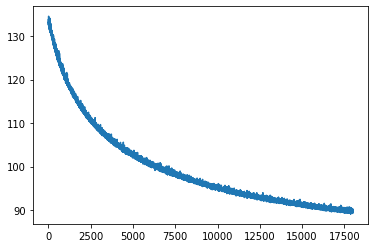

In [122]:
plt.plot(lvae.training_loss_list[2000:])

In [116]:
_,_,decoded = lvae.forward(Y)

In [119]:
torch.round(torch.exp(decoded))

tensor([[1., 1., 0.,  ..., 1., 1., 0.],
        [2., 2., 2.,  ..., 7., 5., 9.],
        [1., 1., 1.,  ..., 1., 0., 0.],
        ...,
        [1., 2., 3.,  ..., 3., 2., 2.],
        [0., 1., 0.,  ..., 1., 2., 1.],
        [0., 2., 1.,  ..., 1., 0., 1.]], grad_fn=<RoundBackward0>)

In [118]:
Y

tensor([[1., 1., 0.,  ..., 2., 2., 0.],
        [2., 0., 3.,  ..., 5., 4., 9.],
        [1., 0., 1.,  ..., 1., 0., 1.],
        ...,
        [4., 1., 5.,  ..., 0., 1., 1.],
        [1., 0., 1.,  ..., 0., 0., 0.],
        [0., 2., 0.,  ..., 2., 0., 1.]])

In [125]:
torch.mean(torch.abs(torch.round(torch.exp(decoded))-Y))

tensor(1.309, grad_fn=<MeanBackward0>)

In [126]:
torch.round(torch.exp(decoded))

tensor([[1., 1., 0.,  ..., 1., 1., 0.],
        [2., 2., 2.,  ..., 7., 5., 9.],
        [1., 1., 1.,  ..., 1., 0., 0.],
        ...,
        [1., 2., 3.,  ..., 3., 2., 2.],
        [0., 1., 0.,  ..., 1., 2., 1.],
        [0., 2., 1.,  ..., 1., 0., 1.]], grad_fn=<RoundBackward0>)

In [135]:
n_ = 24
print(Y[0,n_])
print(torch.round(torch.exp(decoded))[0,n_])

tensor(57.)
tensor(67., grad_fn=<SelectBackward0>)


In [93]:
torch.round(torch.exp(decoded))-Y

tensor([[ 1., -1.,  2.,  ..., -2.,  0.,  0.],
        [ 0., -1.,  2.,  ...,  0., -2., -3.],
        [ 0.,  0.,  0.,  ...,  1.,  1.,  0.],
        ...,
        [-1.,  1.,  0.,  ..., -1., -1.,  1.],
        [ 1.,  1.,  0.,  ...,  1., -2.,  2.],
        [ 1.,  1., -1.,  ..., -2.,  1., -2.]], grad_fn=<SubBackward0>)

In [73]:
Y.argmax(axis = 0)

tensor([ 81, 138,  38,  13,  13, 101,  61,  44, 153, 153,   6,  97, 119,  99,
         97,   8,  12,  12, 182,  31, 112,  33,  74,  40,  41, 129,  35, 110,
         99, 106,   6,   6,   6,   6,   6, 133, 113, 137, 113,  59, 163, 101,
        165, 198,   8,  60, 178, 158,  62, 169])

In [88]:
Y[12,17]

tensor(15.)

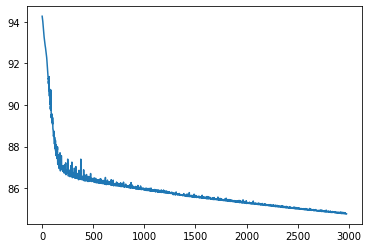

In [369]:
plt.plot(lvae.training_loss_list[20:])

lr :  1e-05
Epoch:1, Training loss:2658141862030159118336.0000
Epoch:2, Training loss:290.9557
Epoch:3, Training loss:107.9141
Epoch:4, Training loss:95.9855
Epoch:5, Training loss:94.2501
Epoch:6, Training loss:93.8206
Epoch:7, Training loss:93.5007
Epoch:8, Training loss:93.3955
Epoch:9, Training loss:93.3636
Epoch:10, Training loss:93.3517
Epoch:11, Training loss:93.3187
Epoch:12, Training loss:93.3048
Epoch:13, Training loss:93.2969
Epoch:14, Training loss:93.2927
Epoch:15, Training loss:93.2910
Epoch:16, Training loss:93.2891
Epoch:17, Training loss:93.2883
Epoch:18, Training loss:93.2877
Epoch:19, Training loss:93.2874
Epoch:20, Training loss:93.2870
Epoch:21, Training loss:93.2865
Epoch:22, Training loss:93.2862
Epoch:23, Training loss:93.2858
Epoch:24, Training loss:93.2854
Epoch:25, Training loss:93.2851
Epoch:26, Training loss:93.2847
Epoch:27, Training loss:93.2842
Epoch:28, Training loss:93.2838
Epoch:29, Training loss:93.2834
Epoch:30, Training loss:93.2830
Epoch:31, Train

Epoch:63, Training loss:nan
Epoch:64, Training loss:nan
Epoch:65, Training loss:nan
Epoch:66, Training loss:nan
Epoch:67, Training loss:nan
Epoch:68, Training loss:nan
Epoch:69, Training loss:nan
Epoch:70, Training loss:nan
Epoch:71, Training loss:nan
Epoch:72, Training loss:nan
Epoch:73, Training loss:nan
Epoch:74, Training loss:nan
Epoch:75, Training loss:nan
Epoch:76, Training loss:nan
Epoch:77, Training loss:nan
Epoch:78, Training loss:nan
Epoch:79, Training loss:nan
Epoch:80, Training loss:nan
Epoch:81, Training loss:nan
Epoch:82, Training loss:nan
Epoch:83, Training loss:nan
Epoch:84, Training loss:nan
Epoch:85, Training loss:nan
Epoch:86, Training loss:nan
Epoch:87, Training loss:nan
Epoch:88, Training loss:nan
Epoch:89, Training loss:nan
Epoch:90, Training loss:nan
Epoch:91, Training loss:nan
Epoch:92, Training loss:nan
Epoch:93, Training loss:nan
Epoch:94, Training loss:nan
Epoch:95, Training loss:nan
Epoch:96, Training loss:nan
Epoch:97, Training loss:nan
Epoch:98, Training l

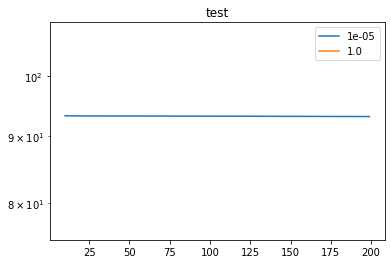

In [399]:
optim = torch.optim.Adamax

lr_list = np.logspace(-5,0,2)
def plot_lr(optimizer, lr_list, nb_iter, name = 'test'):
    list_training_loss = list()
    for lr in lr_list: 
        print('lr : ', lr )
        lvae = PLN_encoder(p,q)
        lvae._train(Y,O,covariates, nb_iter, batch_size = 15 ,optimizer = optim, lr = lr, lr_model = 0.01)
        list_training_loss.append(lvae.training_loss_list)
        
    length = len(list_training_loss[0])

    for i, lr in enumerate(lr_list)  : 
        plt.plot(np.arange(length)[10:] , list_training_loss[i][10:], label = str(lr))

    plt.legend()
    plt.ylim([75,110])
    plt.yscale('log')
    plt.title(name)
    plt.savefig(name)

    plt.show()
    return list_training_loss
        
list_training_loss = plot_lr(optim, lr_list, 200)
    

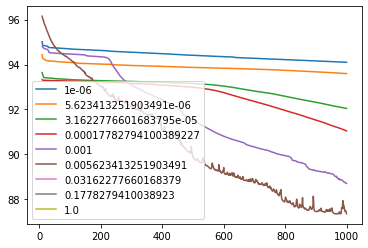

In [373]:
length = len(list_training_loss[0])

for i, lr in enumerate(lr_list)  : 
    plt.plot(np.arange(length)[10:] , list_training_loss[i][10:], label = str(lr))
    
plt.legend()
plt.savefig(name)
plt.show()

lr :  1e-05
Training finished
lr :  6.812920690579608e-05
Training finished
lr :  0.0004641588833612782
Training finished
lr :  0.0031622776601683794
Training finished
lr :  0.021544346900318846
Training finished
lr :  0.14677992676220705
Training finished
lr :  1.0
Training finished


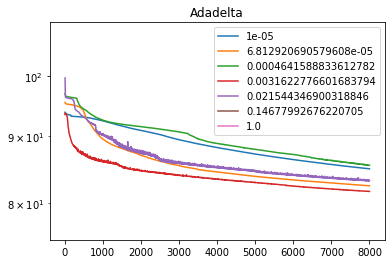

lr :  1e-05
Training finished
lr :  6.812920690579608e-05
Training finished
lr :  0.0004641588833612782
Training finished
lr :  0.0031622776601683794


KeyboardInterrupt: 

In [405]:
def try_optim(dict_optim, lr_list): 
    list_res = list()
    for name, optim in dict_optim.items(): 
        res = plot_lr(optim, lr_list,8000, name = name)
        list_res.append(res)
    return list_res
        
lr_list = np.logspace(-5,0,7)
list_res = try_optim(dict_optim, lr_list)
    

In [ ]:
def try_future_optim(dict_optim, lr_list):
    list_res = list()
    for t in ts : 
        t.join()

In [ ]:
def plot_threading_lr(optim, lr_list, nb_iter):     
    list_training_loss = list()
    for lr in lr_list: 
        lvae = PLN_encoder(p,q)
        t = threading.Thread(target =lvae._train,
              args = [Y,O,covariates, nb_iter, 15 , optim, torch.optim.Rprop, lr, 0.01, False])
        list_training_loss.append(lvae.training_loss_list)
        
        t.start()
        ts.append(t)
        models.append(model)
    for t in ts : 
        t.join()
        
        
        
    for lr in lr_list: 
        print('lr : ', lr )
        lvae = PLN_enocder(p,q)
        lvae._train(Y,O,covariates, nb_iter, batch_size = 15 ,optimizer = optim, lr = lr, lr_model = 0.01)
        list_training_loss.append(lvae.training_loss_list)
        
    length = len(list_training_loss[0])

    for i, lr in enumerate(lr_list)  : 
        plt.plot(np.arange(length)[10:] , list_training_loss[i][10:], label = str(lr))

    plt.legend()
    plt.ylim([75,110])
    plt.yscale('log')
    plt.title(name)
    plt.savefig(name)

    plt.show()

In [396]:
dict_optim = {'Adadelta': torch.optim.Adadelta, 'Adagrad': torch.optim.Adagrad, 
             'Adam': torch.optim.Adam,'Adamax': torch.optim.Adamax,'adamW': torch.optim.AdamW,
              'ASGD': torch.optim.ASGD,'LBFGS': torch.optim.LBFGS
             ,'NAdam': torch.optim.NAdam,'RAdam': torch.optim.RAdam,
              'RMSprop': torch.optim.RMSprop,'Rprop': torch.optim.Rprop,'SGD': torch.optim.SGD,
              'SparseAdam' :torch.optim.SparseAdam, 
               'swa_utils': torch.optim.swa_utils}

<AxesSubplot:>

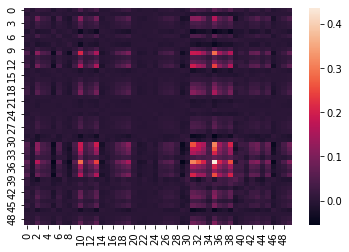

In [36]:
sns.heatmap((lvae.C@(lvae.C.T)).detach())

<AxesSubplot:>

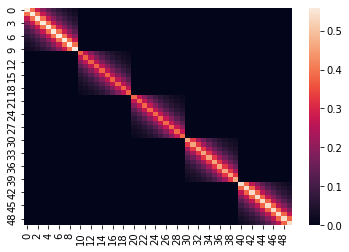

In [116]:
sns.heatmap(Sigma_sampling)

In [223]:
true_beta

tensor([[ 0.064, -0.397, -0.873,  0.158, -0.723,  0.201,  0.560, -0.023, -0.044,
          0.277,  0.036,  0.946, -0.492,  0.522, -0.925, -1.489,  0.554,  0.301,
         -0.830,  1.673, -0.473, -0.289,  1.078,  0.134,  0.236, -0.989,  0.088,
          0.017,  1.008, -0.490, -0.681,  0.825,  0.046, -0.142,  0.093, -0.269,
          0.574,  0.278, -0.111, -0.266,  0.594,  0.398,  1.303, -0.834,  0.335,
         -0.355, -0.147,  0.139,  1.621, -0.060],
        [ 0.370,  0.268, -0.047, -0.593,  0.188, -0.157, -0.636,  1.797, -0.120,
         -0.178,  0.101, -0.822,  0.723, -0.292,  0.979, -0.017,  0.496, -0.649,
         -0.886,  0.266, -0.708,  0.751, -0.134,  1.159,  0.045, -0.231, -1.042,
         -0.820, -0.664,  0.529,  0.893, -0.314,  1.297,  0.318, -0.651,  0.933,
          0.573,  0.081, -0.884, -0.513, -0.101, -0.763, -0.407,  0.341, -0.641,
          0.014, -0.054, -0.048,  1.041, -0.167]])

In [224]:
lvae.beta

tensor([[ 0.080, -0.345, -0.881,  0.123, -0.785,  0.119,  0.476, -0.108, -0.062,
          0.202,  0.051,  1.105, -0.359,  0.507, -0.857, -1.460,  0.560,  0.341,
         -0.796,  1.654, -0.598, -0.154,  1.241,  0.134,  0.285, -0.973,  0.191,
          0.084,  1.210, -0.550, -0.552,  0.876,  0.270,  0.036,  0.041, -0.315,
          0.638,  0.317, -0.174, -0.300,  0.597,  0.443,  1.194, -0.853,  0.299,
         -0.453, -0.087,  0.179,  1.675, -0.249],
        [ 0.462,  0.513,  0.091, -0.462,  0.299, -0.113, -0.690,  1.878, -0.211,
         -0.104,  0.125, -0.635,  0.759, -0.371,  0.938,  0.032,  0.486, -0.646,
         -0.912,  0.297, -0.663,  0.762, -0.119,  1.249,  0.020, -0.270, -1.123,
         -0.847, -0.711,  0.547,  0.863, -0.242,  1.258,  0.325, -0.652,  0.938,
          0.591,  0.143, -0.825, -0.436, -0.029, -0.688, -0.441,  0.455, -0.619,
          0.151, -0.072, -0.078,  1.018, -0.187]], requires_grad=True)

In [244]:
lvae.beta

tensor([[ 0.081, -0.344, -0.881,  0.124, -0.786,  0.119,  0.477, -0.111, -0.062,
          0.202,  0.050,  1.104, -0.360,  0.506, -0.857, -1.460,  0.559,  0.340,
         -0.795,  1.654, -0.597, -0.154,  1.240,  0.134,  0.286, -0.969,  0.190,
          0.083,  1.208, -0.550, -0.551,  0.876,  0.270,  0.036,  0.039, -0.315,
          0.637,  0.316, -0.173, -0.301,  0.597,  0.445,  1.196, -0.854,  0.300,
         -0.451, -0.086,  0.179,  1.677, -0.248],
        [ 0.461,  0.512,  0.091, -0.461,  0.302, -0.112, -0.690,  1.879, -0.211,
         -0.104,  0.125, -0.637,  0.761, -0.373,  0.939,  0.030,  0.487, -0.647,
         -0.912,  0.298, -0.664,  0.761, -0.118,  1.248,  0.019, -0.272, -1.123,
         -0.848, -0.711,  0.548,  0.863, -0.242,  1.258,  0.326, -0.652,  0.940,
          0.591,  0.143, -0.827, -0.437, -0.029, -0.689, -0.441,  0.459, -0.618,
          0.151, -0.072, -0.078,  1.019, -0.188]], requires_grad=True)

In [262]:
fastpca = models.fastPLNPCA(q)

In [270]:
fastpca.fit(pd.DataFrame(Y),pd.DataFrame(O),pd.DataFrame(covariates), verbose = True, N_iter_max = 500)

Iteration number:  0
-------UPDATE-------
Delta :  1
Tolerance 0.001 reached in 15 iterations


Last ELBO : -76.81670597940432
Dimension of the latent space : 5


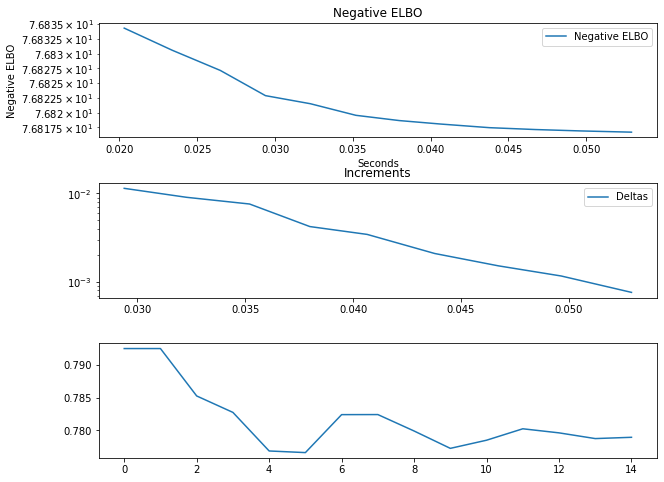

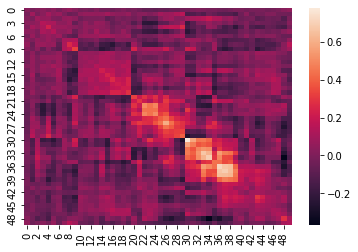

In [302]:
print(fastpca)

<AxesSubplot:>

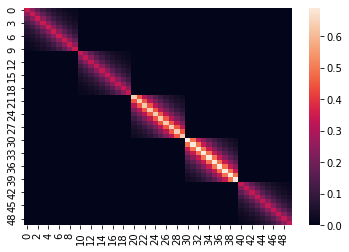

In [272]:
sns.heatmap(Sigma_sampling)

In [125]:
import PLNpy
from PLNpy import models
import pandas as pd

